In [3]:
import numpy as np
from scipy.optimize import linprog

# Profit per unit
profit = [-40, -30]

# Machine and Labour constraints
A = [
    [2, 1],
    [1, 2]
]

b = [100, 80]

# Solve Linear Programming Problem
result = linprog(
    profit,
    A_ub=A,
    b_ub=b,
    bounds=[(0, None), (0, None)],
    method='highs'
)

# Optimal units
A_units = result.x[0]
B_units = result.x[1]

# Maximum profit
max_profit = 40 * A_units + 30 * B_units

print("Optimal Number of Product A:", A_units)
print("Optimal Number of Product B:", B_units)
print("Maximum Profit: ₹", max_profit)

# Resource usage
machine_used = 2 * A_units + B_units
labour_used = A_units + 2 * B_units

print("Machine Hours Used:", machine_used)
print("Labour Hours Used:", labour_used)

Optimal Number of Product A: 40.0
Optimal Number of Product B: 20.0
Maximum Profit: ₹ 2200.0
Machine Hours Used: 100.0
Labour Hours Used: 80.0


Daily Demand:
[24 30 15 43 40 44 44 23 24 15 31 26 39 48 23 29 28 20 28 40 28 43 37 45
 45 40 27 16 46 42]

Inventory Level: 30
Day | Demand | Sold | Left | Shortage
1 | 24 | 24 | 6 | 0
2 | 30 | 30 | 0 | 0
3 | 15 | 15 | 15 | 0
4 | 43 | 30 | 0 | 13
5 | 40 | 30 | 0 | 10
6 | 44 | 30 | 0 | 14
7 | 44 | 30 | 0 | 14
8 | 23 | 23 | 7 | 0
9 | 24 | 24 | 6 | 0
10 | 15 | 15 | 15 | 0
11 | 31 | 30 | 0 | 1
12 | 26 | 26 | 4 | 0
13 | 39 | 30 | 0 | 9
14 | 48 | 30 | 0 | 18
15 | 23 | 23 | 7 | 0
16 | 29 | 29 | 1 | 0
17 | 28 | 28 | 2 | 0
18 | 20 | 20 | 10 | 0
19 | 28 | 28 | 2 | 0
20 | 40 | 30 | 0 | 10
21 | 28 | 28 | 2 | 0
22 | 43 | 30 | 0 | 13
23 | 37 | 30 | 0 | 7
24 | 45 | 30 | 0 | 15
25 | 45 | 30 | 0 | 15
26 | 40 | 30 | 0 | 10
27 | 27 | 27 | 3 | 0
28 | 16 | 16 | 14 | 0
29 | 46 | 30 | 0 | 16
30 | 42 | 30 | 0 | 12
Total Sold: 806
Total Shortage: 177

Inventory Level: 40
Day | Demand | Sold | Left | Shortage
1 | 24 | 24 | 16 | 0
2 | 30 | 30 | 10 | 0
3 | 15 | 15 | 25 | 0
4 | 43 | 40 | 0 | 3
5 | 40 | 40 | 0 | 0

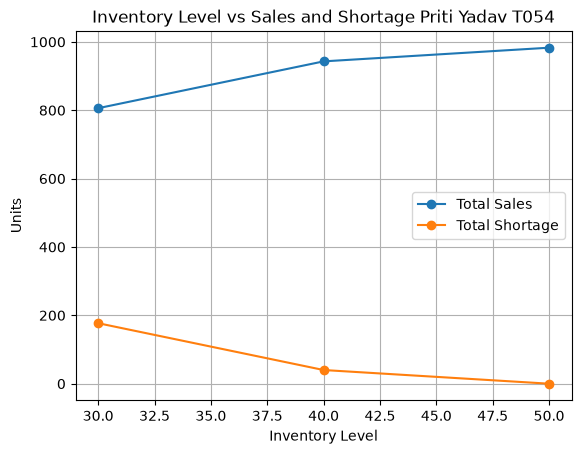

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Generate demand for 30 days
np.random.seed(10)
demand = np.random.randint(15, 51, 30)

print("Daily Demand:")
print(demand)

# Inventory levels
inventory_levels = [30, 40, 50]

results = []

for inventory in inventory_levels:

    sold = np.minimum(demand, inventory)
    shortage = np.maximum(demand - inventory, 0)
    inventory_left = np.maximum(inventory - demand, 0)

    print("\nInventory Level:", inventory)

    print("Day | Demand | Sold | Left | Shortage")

    for i in range(30):
        print(i + 1, "|", demand[i], "|",
              sold[i], "|", inventory_left[i],
              "|", shortage[i])

    total_sold = sold.sum()
    total_shortage = shortage.sum()

    print("Total Sold:", total_sold)
    print("Total Shortage:", total_shortage)

    results.append([
        inventory,
        total_sold,
        total_shortage
    ])

# Create DataFrame
df = pd.DataFrame(
    results,
    columns=["Inventory Level", "Total Sales", "Total Shortage"]
)

print("\nSimulation Results:")
print(df)

# Create chart
plt.plot(df["Inventory Level"],
         df["Total Sales"],
         marker="o",
         label="Total Sales")

plt.plot(df["Inventory Level"],
         df["Total Shortage"],
         marker="o",
         label="Total Shortage")

plt.xlabel("Inventory Level")
plt.ylabel("Units")
plt.title("Inventory Level vs Sales and Shortage Priti Yadav T054")
plt.legend()
plt.grid()
plt.show()